In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

import cmasher as cmr
import numpy as np
import pickle
plt.rcParams.update({'font.size': 14})

### Increasing Randomness

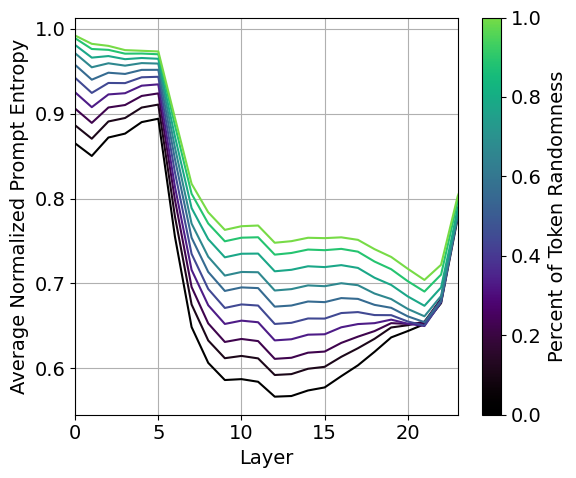

In [2]:
with open('small_results/pythia_randomness.pkl', 'rb') as f:
    randomness_results = pickle.load(f)

fig, ax = plt.subplots(figsize=(6, 5))
randomness_levels = list(randomness_results.keys())
colors = cmr.lavender(np.linspace(0, 1, len(randomness_levels)))
cmap = cmr.lavender
norm = plt.Normalize(vmin=0, vmax=1)

PLOT_STDEV = False
PLOT_DIPTEST = False
normalization = 'maxEntropy'

for randomness_level, color in zip(randomness_levels, colors):
    if PLOT_STDEV:
        stddev = np.std(randomness_results[randomness_level][normalization], axis=0)
    elif PLOT_DIPTEST:
        layerwise_dipstats = [diptest.dipstat(randomness_results[randomness_level][normalization][:, layer]) for layer in range(randomness_results[randomness_level][normalization].shape[1])]
        ax.plot(layerwise_dipstats, color=color)
    else:
        ax.plot(randomness_results[randomness_level][normalization].mean(axis=0), color=color)
ax.set_xlabel("Layer")
ax.set_ylabel("Average Normalized Prompt Entropy")
#ax.set_ylim(0, 1)
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Percent of Token Randomness')
plt.tight_layout()
plt.savefig('figures/pythia_increasing_randomness.pdf')

### Sentences with Increasing Repetition

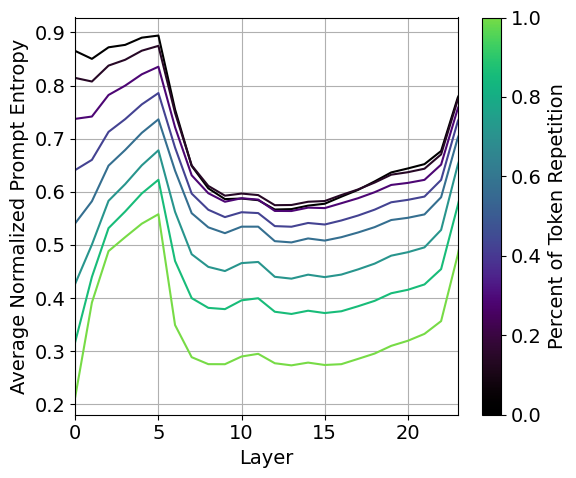

In [3]:
with open('small_results/pythia_repetition.pkl', 'rb') as f:
    repetition_results = pickle.load(f)

# plot pythia repetition
fig, ax = plt.subplots(figsize=(6, 5))
repetition_levels = list(repetition_results.keys())
colors = cmr.lavender(np.linspace(0, 1, len(repetition_levels)))
cmap = cmr.lavender
norm = plt.Normalize(vmin=0, vmax=1)

PLOT_STDEV = False
PLOT_DIPTEST = False

for repetition_level, color in zip(repetition_levels, colors):
    if PLOT_STDEV:
        stddev = np.std(repetition_results[repetition_level]['maxEntropy'], axis=0)
        ax.plot(stddev, color=color)
    elif PLOT_DIPTEST:
        layerwise_dipstats = [diptest.dipstat(repetition_results[repetition_level]['maxEntropy'][:, layer]) for layer in range(repetition_results[repetition_level]['maxEntropy'].shape[1])]
        ax.plot(layerwise_dipstats, color=color)
    else:
        ax.plot(repetition_results[repetition_level]['maxEntropy'].mean(axis=0), color=color)
ax.set_xlabel("Layer")
ax.set_ylabel("Average Normalized Prompt Entropy")
#ax.set_ylim(0, 1)
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Percent of Token Repetition')
plt.tight_layout()
plt.savefig('figures/pythia_increasing_repetition.pdf')

### Random Sentences of Increasing Length

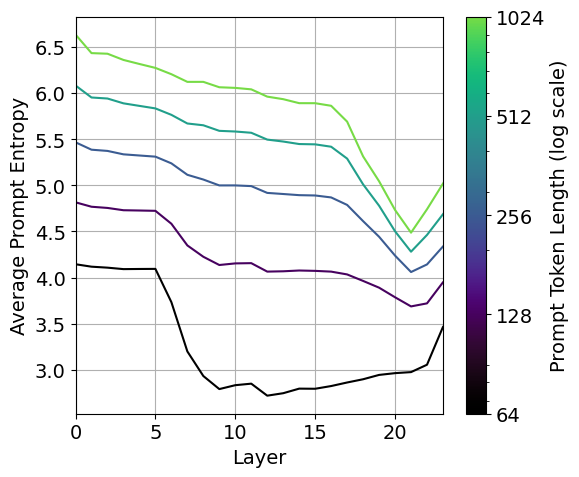

In [4]:
import matplotlib

results = pickle.load(open(f'small_results/pythia_random_of_differing_lengths.pkl', 'rb'))
results.pop(2048)

fig, ax = plt.subplots(figsize=(6, 5))
lengths = list(results.keys())
log_lengths = np.log2(lengths)  # Convert lengths to log scale
colors = cmr.lavender(np.linspace(0, 1, len(lengths)))
cmap = cmr.lavender
norm =  matplotlib.colors.LogNorm(vmin=min(lengths), vmax=max(lengths))

normalization = 'raw'

for idx, (length, entropy) in enumerate(results.items()):
    ax.plot(entropy[normalization].mean(axis=0), color=colors[idx], label=f'Length: {length}')

ax.set_xlabel("Layer")
if normalization == 'maxEntropy':
    ax.set_ylabel("Average Normalized Prompt Entropy")
    ax.set_ylim(0, 1)
else:
    ax.set_ylabel("Average Prompt Entropy")
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Prompt Token Length (log scale)')
cbar.set_ticks(lengths)
cbar.set_ticklabels(lengths)
plt.tight_layout()
plt.savefig(f'figures/pythia_random_of_differing_lengths_{normalization}.pdf')

## Behavior of matrix-based entropy

In [5]:
def get_eigenvalues_with_power_law(N, beta):
    """
    Make a matrix with eigenvalues that follow a power law distribution,
    same eigenvalues as idendity
    """
    eigenvalues = np.linspace(1, N, N)**-beta
    eigenvalues /= eigenvalues.sum()

    # the formula for the i-th largest eigenvalue is i**-beta
    return eigenvalues

def calculate_number_of_principal_components_to_preserve_variance(eigenvalues, threshold=0.95):
    """
    Calculate the number of principal components to preserve 95% of the variance
    """
    total_variance = eigenvalues.sum()

    variance = 0
    for i, eigenvalue in enumerate(eigenvalues):
        variance += eigenvalue
        if variance >= threshold * total_variance:
            return i + 1

    return len(eigenvalues)

def get_entropy_from_eigenvalues(eigenvalues, alpha=1):
    """
    Calculate the entropy of the eigenvalues
    """
    if alpha == 1:
        entropy = -np.sum(eigenvalues * np.log(eigenvalues))
    else:
        entropy = (1 / (1 - alpha)) * np.log(np.sum(eigenvalues**alpha))

    return entropy / np.log(len(eigenvalues))

def get_logdet_entropy_from_eigenvalues(eigenvalues):
    """
    Calculate the entropy of the eigenvalues using the log determinant
    """
    N = len(eigenvalues)
    logdet = np.sum(np.log(1+eigenvalues))
    logdet -= np.log(2)
    return logdet


[0.30188590475686417, 0.3018364521564717, 0.30165372739644447, 0.3012657985167685, 0.3005649019565084, 0.29939676035801777, 0.2975541255992191, 0.2947814747137939, 0.29079809820303415, 0.28534218454278604, 0.27822852292232136, 0.26940180783419787, 0.25896437065753164, 0.24716605973540062, 0.23436032932059614, 0.2209438023033099, 0.20729933411156498, 0.19375599065523408, 0.1805696746654758, 0.16792092372783496, 0.15592349177774478, 0.14463769732206477, 0.13408434760237797, 0.12425697473190889, 0.11513154350045862, 0.10667362505730871, 0.09884341387398687, 0.09159907293337854, 0.08489886126911583, 0.07870241442471027, 0.07297145712272546, 0.06767014785629977, 0.062765192871446, 0.05822582137508536, 0.05402368176524941, 0.050132696879904404, 0.04652890178318836, 0.04319027818625365, 0.04009659358123374, 0.03722924939411265, 0.03457114014751661, 0.032106524243103896, 0.02982090618053912, 0.027700929603391544, 0.02573428035848213, 0.023909598684415556, 0.022216399649939045, 0.02064500100899

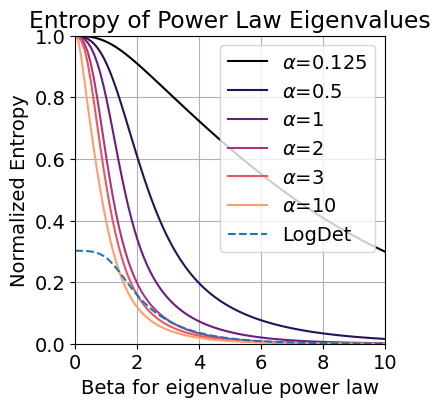

In [6]:
import matplotlib.pyplot as plt
import numpy as np
alphas = [1/8, 1/2, 1, 2, 3, 10]
betas = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('magma')

colors = cmap(np.linspace(0, 0.8, len(alphas)))  # Changed start from 0 to 0.2 to make endpoint darker
for alpha, color in zip(alphas, colors):
    eigenvalue_sets = [get_eigenvalues_with_power_law(100, beta) for beta in betas]
    entropies = [get_entropy_from_eigenvalues(eigenvalues, alpha) for eigenvalues in eigenvalue_sets]
    ax.plot(betas, entropies, label=f'$\\alpha$={alpha}', color=color)

logdet_entropies = [get_logdet_entropy_from_eigenvalues(eigenvalues) for eigenvalues in eigenvalue_sets]
ax.plot(betas, logdet_entropies, label='LogDet', linestyle='--')
print(logdet_entropies)
ax.set_title("Entropy of Power Law Eigenvalues")
ax.set_xlabel("Beta for eigenvalue power law")
ax.set_ylabel("Normalized Entropy")
ax.grid()
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)

plt.legend()
plt.savefig('figures/power_law_entropy.pdf')